In [1]:
from __future__ import print_function
import datetime
import math
import numpy as np
import pandas as pd
import itertools # for calculating the Cartesian product
from itertools import product
from tabulate import tabulate # for displaying the game
import copy
from IPython.display import clear_output
import json
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

from tqdm import tnrange, tqdm_notebook
import seaborn as sns
import pandas as pd 
import matplotlib.pyplot as plt
from numba import jit

pd.set_option('mode.chained_assignment', None) # to stop a displaying a warning

In [2]:

@jit
def _payout(gm_matrix, act1, act2):
    return gm_matrix[act1][act2]

def generate_game_matrix(cc, cd, dc, dd):
    return np.array([[cc, cd], [dc, dd]])

class StrategicGame():
    '''
    A strategic game
    role: is a list of the types of players in a game.  E.g., in a 2-player game, it might be [row, column]
         the order of the list gives the order for the profiles.   E.g., [row, col] (where row=0 and col=1)
    strategies: for each role, the strategies available to that role.   It is a dictionary associating each 
         role (element of self.roles) with a tuple of strategies (the data type of the strategy does not matter)
         E.g., {row:(0,1), col:(2,3)}
    utilities: for each role, the utilities associated with each profile.   It is a dictionary associating each 
         role with a dictionary assigning number to each profile (a tuple of strategies, one from each role)
         E.g., {row:{(0,2):1, (0,3):0, (1,2):0, (1,3):1}, col:{(0,2):1, (0,3):0, (1,2):0, (1,3):1}}
    strateg_fmt: Used for displaying a game: It is a dictionary that assigns to each role, a dictionary that 
         gives a string for each strategy.  E.g., {row: {0: "U", 1: "D"}, col: {2:"L", 3:"R"}}
    '''
    def __init__(self, roles, strategies, utilities, strategy_fmt=None):
        self.roles = roles  
        self.strategies = strategies
        self.utilities = utilities
        self.gm_matrix = None
        self.strategy_fmt = strategy_fmt # dictionary that makes displaying a game prettier
        assert self.validate(),\
        "Error: strategies and utilities are not coherent: Strategies: {}, Utilities: {}".format(str(strategies), 
                                                                                                 str(utilities))
    
    def create_game_matrix(self, cc, cd, dc, dd):
        '''for optimization'''
        self.gm_matrix = generate_game_matrix(cc, cd, dc, dd)
        
    @property 
    def profiles(self):
        return list(itertools.product(*[self.strategies[_r] for _r in self.roles]))
    
    def update_utilities(self, utilities):
        
        self.utilities = utilities
  
    def utility_as_profile(self, prof, rounded=False):
        # given a profile, return the utility as a tuple
        return tuple([self.utilities[_r][prof] for _r in self.roles]) if not rounded else tuple([round(self.utilities[_r][prof],2) for _r in self.roles])

    def _utility(self, role, prof):
        # return the utility of a role for a profile
        # Note: this is a private method (should be accessed through the player utilitiy method)
        return self.utilities[role][prof]
    
    def payout2(self, act1, act2):
        return _payout(self.gm_matrix, act1, act2)

    def payout(self, profile):
        # profile is a named tuple: role: act

        assert sorted(profile.keys()) == sorted(self.roles), "profile must have a act for each role: {}".format(self.roles)
        return {r:self._utility(r, tuple(profile[r] for r in self.roles)) for r in self.roles}

    def is_pd(self, coop_act, defect_act):
        '''return True is the game is a prisoner's dilemma
        input is the strategy that is the coop act and the strategy that is the defect act
        '''
        r1, r2 = self.roles
        
        cc = self.payout({r1: coop_act, r2:coop_act})[r1]
        cd = self.payout({r1: coop_act, r2:defect_act})[r1]
        dc = self.payout({r1: defect_act, r2: coop_act})[r1]
        dd = self.payout({r1: defect_act, r2: defect_act})[r2]
        
        return dc > cc > dd > cd

    def payout_from_tuple(self, act1, act2):
        # profile is a named tuple: role: act

        r1, r2 = self.roles
        return self.payout({r1: act1, r2:act2})[r1]
    
    def validate(self):
        '''
        Validate that the strategies and the utilities actually for a strategic game
        '''
        is_valid = True
        
        # make sure that the keys of the strategies and utilities are the same
        for r in self.strategies.keys():
            if r not in self.utilities.keys():
                is_valid = False
        # make sure that  all profiles have a utility associated with it
        for prof in list(itertools.product(*[self.strategies[_r] for _r in self.roles])):
            prof = tuple(prof)
            for r in self.utilities: 
                if prof not in self.utilities[r].keys():
                    is_valid = False 
        return is_valid

    def act_as_str(self, a):
        act_str = str(a)
        if self.strategy_fmt is not None:
            for roles in self.strategy_fmt.keys():
                if a in self.strategy_fmt[roles].keys():
                    act_str = self.strategy_fmt[roles][a]
        return act_str
    
    def __str__(self):
        '''
        pretty print a game
        NOTE: Assumes that the game has only 2 players
        '''
        if self.strategy_fmt is not None:
            row_1 = [''] + [self.strategy_fmt[self.roles[1]][_a] for _a in self.strategies[self.roles[1]]]
            rows = [[self.strategy_fmt[self.roles[0]][_r]] + [self.utility_as_profile((_r,_c),rounded=True)
                                                              for _c in self.strategies[self.roles[1]]] 
                    for _r in self.strategies[self.roles[0]]]
        else:
            row_1 = [''] + [_a for _a in self.strategies[self.roles[1]]]
            rows = [[_r] + [self.utility_as_profile((_r,_c),rounded=True) for _c in self.strategies[self.roles[1]]] 
                    for _r in self.strategies[self.roles[0]]]
        return tabulate([row_1]+rows, tablefmt="grid")
    
def generate_symmetric_game(acts, payouts, acts_fmt):    
    row, col = ('r', 'c')
    strategies = {row: tuple(acts),
                  col: tuple(acts)}
    
    utilities = {row:{prf: payouts[prf] for prf in payouts.keys()},
                 col:{prf: payouts[(prf[1], prf[0])] for prf in payouts.keys()}}

    return StrategicGame([row,col], strategies, utilities,
                         strategy_fmt={row:{a:acts_fmt[a] for a in acts}, 
                                       col:{a:acts_fmt[a] for a in acts}})


In [3]:
@jit
def _move(indices, probs):
    return np.random.choice(indices, p=probs)

class Player():
    '''
    A player in a the simulation
    '''
    
    def __init__(self, 
                 acts, 
                 coop_act, 
                 defect_act,
                 tolerance,
                 adv_mutation_rate,
                 weight_of_present_for_move,
                 weight_of_present_for_adv,
                 move_mutation_rate,
                 move_increment,
                 act_inclinations = None, 
                 act_estimates = None, 
                 adv_estimates = None, 
                 adv_type = None):
        
        self.acts = acts
        self.adv_type = np.random.choice(acts) if adv_type == None else adv_type
        self.inc = {a: float(1.0 / float(len(self.acts))) 
                    for a in self.acts} if act_inclinations is None else act_inclinations 
        
        self.act_est = {a:0 for a in self.acts} if act_estimates is None else act_estimates
        self.adv_est = {a:0 for a in self.acts} if adv_estimates is None else adv_estimates  
        
        assert coop_act in acts, "The cooperative act {} must be an act {}".format(coop_act, acts)
        assert defect_act in acts, "The defect act {} must be an act {}".format(defect_act, acts)
        
        self.coop = coop_act 
        self.defect = defect_act
        self.tolerance = tolerance
        self.adv_mutation_rate = adv_mutation_rate
        self.weight_of_present_for_move = weight_of_present_for_move
        self.weight_of_present_for_adv = weight_of_present_for_adv
        self.move_mutation_rate = move_mutation_rate
        self.move_increment = move_increment
        self.total_payout = 0
        self.num_moves = 0
        self.num_adv_mutations = 0
        
    def move(self):
        
        moves = [a for a in self.inc.keys()]
        probs = [self.inc[a] for a in self.inc.keys()]
        move_idx = _move(range(0,len(moves)),probs)
        return moves[move_idx]
    
    def advocate(self):
        return self.adv_type         
       
    @property
    def pr_coop(self):
        return self.inc[self.coop]
    
    @property
    def pr_defect(self):
        return self.inc[self.defect]
    
    @property
    def est_coop(self):
        return self.act_est[self.coop]
    
    @property
    def est_defect(self):
        return self.act_est[self.defect]
    
    @property
    def avg_payout(self):
        return float(self.total_payout) / self.num_moves if self.num_moves > 0 else 0
    
    def update_payout(self, payout):
        self.total_payout += payout
        self.num_moves += 1
        
    def update_estimates(self, payout, move, adv): 
        
        '''TODO: Should an advocacy-move combination (e.g., (cAdv, c)) update both (cAdv) and (c) estimates, 
        or a single estimate (cAdv, c)? Doing former approach here'''
        
        self.act_est = {a: self.weight_of_present_for_move * payout + (1-self.weight_of_present_for_move) * self.act_est[a] 
                        if a == move else self.act_est[a] for a in self.acts}
  
        self.adv_est = {a: self.weight_of_present_for_adv * payout + (1-self.weight_of_present_for_adv) * self.adv_est[a] 
                        if a == adv else self.adv_est[a] for a in self.acts}

    def update_advocate_type(self):

        if  (self.adv_est[self.coop] - self.adv_est[self.defect]) >= self.tolerance:
            self.adv_type = self.coop
        elif  (self.adv_est[self.defect] - self.adv_est[self.coop]) > self.tolerance:
            self.adv_type = self.defect
            
        if np.random.rand() < self.adv_mutation_rate: 
            # mutate the advocate type
            self.num_adv_mutations += 1
            self.adv_type = self.defect if self.adv_type ==  self.coop else self.coop
     
    def update_inclinations(self):
        
        if abs(self.est_coop - self.est_defect) > self.tolerance:
            chance_of_c = self.pr_coop + (self.est_coop - self.est_defect) * self.move_increment

            self.inc[self.coop] = chance_of_c
            self.inc[self.defect] = 1 - chance_of_c
            
            if chance_of_c > (1 - self.move_mutation_rate): 
                self.inc[self.coop] = 1-self.move_mutation_rate
                self.inc[self.defect] = self.move_mutation_rate

            elif chance_of_c < self.move_mutation_rate:
                self.inc[self.coop] = self.move_mutation_rate
                self.inc[self.defect] = 1-self.move_mutation_rate
            

            

In [4]:

@jit
def select_player_indices(num_players):
    p1_idx, p2_idx = np.random.randint(0,num_players,2)
    while p1_idx == p2_idx: 
        p1_idx, p2_idx = np.random.randint(0,num_players,2)
    return p1_idx, p2_idx

@jit 
def _flip(bias):
    return np.random.rand() > bias

class SimulationSymmetricGame():
    
    def __init__(self, 
                 acts, 
                 payouts,
                 max_pos_pressure, 
                 max_neg_pressure,
                 num_players, 
                 num_rounds, 
                 acts_fmt,  
                 coop_act, 
                 defect_act,
                 tolerance,
                 adv_mutation_rate,
                 weight_of_present_for_move,
                 weight_of_present_for_adv,
                 move_increment,
                 move_mutation_rate,
                 adv_conservativity,
                 move_conservativity):
        
        self.acts = acts
        # create the game
        self.game = generate_symmetric_game(acts, payouts, {coop_act:"C", defect_act:"D"})   
        self.game.create_game_matrix(payouts[(coop_act, coop_act)], 
                                     payouts[(coop_act, defect_act)], 
                                     payouts[(defect_act, coop_act)], 
                                     payouts[(defect_act, defect_act)])

        self.num_rounds = num_rounds
        self.num_players = num_players
        self.base_payouts = payouts

        self.coop = coop_act
        self.defect = defect_act
        
        # create players
        init_act_estimates = {a: np.average([payouts[prf] for prf in payouts.keys() if prf[0] == a]) 
                              for a in acts}
        init_act_inclinations = {a: float(init_act_estimates[a]) / float(sum(init_act_estimates.values())) for a in acts}
        
        init_adv_estimates = {a: np.average([payouts[prf] for prf in payouts.keys() if prf[0] == a]) 
                              for a in acts}

        self.players = [Player(acts, 
                               coop_act,
                               defect_act,
                               tolerance,
                               adv_mutation_rate,
                               weight_of_present_for_move,
                               weight_of_present_for_adv,
                               move_mutation_rate,
                               move_increment,
                               act_inclinations = copy.deepcopy(init_act_inclinations), 
                               act_estimates = copy.deepcopy(init_act_estimates), 
                               adv_estimates = copy.deepcopy(init_adv_estimates)) for _ in range(num_players)]

        self.adv_conservativity = adv_conservativity
        self.move_conservativity = move_conservativity
        self.max_pos_pressure = max_pos_pressure
        self.max_neg_pressure = max_neg_pressure
        
        self.adv_mutation_rate = adv_mutation_rate # needed to find max C values
        self.move_mutation_rate = move_mutation_rate # needed to find max Adv C values
        self.move_increment = move_increment
        self.tolerance = tolerance
        
        self.weight_of_present_for_move = weight_of_present_for_move
        self.weight_of_present_for_adv = weight_of_present_for_adv
        
        self.results = [{"players":copy.deepcopy(self.players),
                         "avg_prob_coop": self.avg_prob_coop(), 
                         "avg_prob_defect":self.avg_prob_defect(), 
                         "p1_payout": 0,
                         "p2_payout": 0,
                         "updated_game": False,
                         "is_pd": self.game.is_pd(self.coop, self.defect),                         
                         "p1_cd_est_diff": 0,
                         "p2_cd_est_diff": 0,                                 
                         "num_adv_coop":self.num_advocating(self.coop),
                         "num_adv_defect":self.num_advocating(self.defect),
                         "game":self.game}] 
    
    def create_players(self, player_data):
        
        new_players = list()
        for pdata in player_data:
            p = Player(self.acts,
                       self.coop,
                       self.defect,
                       self.tolerance,
                       self.adv_mutation_rate,
                       self.weight_of_present_for_move,
                       self.weight_of_present_for_adv,
                       self.move_mutation_rate,
                       self.move_increment,
                       act_inclinations = copy.deepcopy(pdata[1]), 
                       act_estimates = copy.deepcopy(pdata[2]), 
                       adv_estimates = copy.deepcopy(pdata[3]))
            p.adv_type = pdata[0]
            new_players.append(p)
        self.num_players = len(player_data)
        self.players = new_players
        
    def avg_prob_coop(self):
        
        return float(sum(p.pr_coop for p in self.players)) / float(self.num_players)
    
    def avg_prob_defect(self):
        
        return float(sum(p.pr_defect for p in self.players)) / float(self.num_players)

    def num_advocating(self, act):        
        """return the number of players advocating act"""
        
        return len([p for p in self.players if p.advocate() == act])

    def payout(self, move1, move2):
        '''return the payout of the current game given move1, move2'''
        
        r1, r2 = self.game.roles
        return self.game.payout({r1:move1, r2:move2})[r1]

    def update_game(self):
        '''Note: assumes that there are only two acts'''
        
        profiles = list(product(self.acts, self.acts))

        # find proportions advocating C and proportion advocating D
        proportion_adv_c = float(self.num_advocating(self.coop)) / self.num_players
        proportion_adv_d = (1-proportion_adv_c)
        
        pos_pressure = self.max_pos_pressure * (2 * proportion_adv_c -1) if proportion_adv_c > 0.5 else self.max_pos_pressure * (2 * proportion_adv_d - 1)
        neg_pressure = self.max_neg_pressure * (2 * proportion_adv_c -1) if proportion_adv_c > 0.5 else self.max_neg_pressure * (2 * proportion_adv_d - 1)
    
        if proportion_adv_c > 0.5:
            new_payouts = {prf:None for prf in profiles}
            for prf in profiles:
                if prf[0] == self.coop:
                    new_payouts[prf] = self.base_payouts[prf] + pos_pressure
                elif prf[0] == self.defect:
                    new_payouts[prf] = self.base_payouts[prf] - neg_pressure
        else:
            new_payouts = {prf:None for prf in profiles}
            for prf in profiles:
                if prf[0] == self.coop:
                    new_payouts[prf] = self.base_payouts[prf] - neg_pressure
                elif prf[0] == self.defect:
                    new_payouts[prf] = self.base_payouts[prf] + pos_pressure
        # now update the utilities in the game
        row, col = self.game.roles 
        new_utilities = {row:{prf: new_payouts[prf] for prf in new_payouts.keys()},
                         col:{prf: new_payouts[(prf[1], prf[0])] for prf in new_payouts.keys()}}


        self.game.update_utilities(new_utilities)
        self.game.create_game_matrix(new_payouts[(self.coop, self.coop)],
                                     new_payouts[(self.coop, self.defect)],
                                     new_payouts[(self.defect, self.coop)],
                                     new_payouts[(self.defect, self.defect)])
           
    def step(self, rnum):
        
        # choose 2 players
        p1_idx, p2_idx = select_player_indices(len(self.players))
        p1, p2 = self.players[p1_idx], self.players[p2_idx]
        r1, r2 = self.game.roles        
        #p1, p2 = np.random.choice(self.players, 2, replace=False)
        #r1, r2 = self.game.roles
        
        # get the player's moves
        p1_move = p1.move()
        p2_move = p2.move()
        
        # calculate payouts for each player
        #p1_payout = self.game.payout({r1:p1_move, r2:p2_move})[r1]
        #p2_payout = self.game.payout({r1:p1_move, r2:p2_move})[r2]
        
        p1_payout = self.game.payout2(p1_move, p2_move)
        p2_payout = self.game.payout2(p2_move, p1_move)
        
        # what do p1/p2 advocate? 
        p1_adv = p1.advocate()
        p2_adv = p2.advocate()
        
        # update payouts and estimates for the players
        p1.update_payout(p1_payout)
        p2.update_payout(p2_payout)
        
        p1.update_estimates(p1_payout, p1_move, p1_adv) 
        p2.update_estimates(p2_payout, p2_move, p2_adv) 
        
        should_update_game = False
        p1_did_update_inc = False
        p1_did_update_adv = False
        p2_did_update_inc = False
        p2_did_update_adv = False
        
        if _flip(self.adv_conservativity): 
            p1.update_advocate_type()
            p1_did_update_adv = p1.advocate() != p1_adv
            should_update_game =  p1.advocate() != p1_adv

        if _flip(self.adv_conservativity): 
            p2.update_advocate_type()
            p2_did_update_adv = p2.advocate() != p2_adv
            should_update_game =  p2.advocate() != p2_adv

        if _flip(self.move_conservativity): 
            p1.update_inclinations()
            p1_did_update_inc = True
                
        if _flip(self.move_conservativity): 
            p2.update_inclinations()
            p2_did_update_inc = True
            
        if should_update_game:
            self.update_game()
        

        return id(p1), p1_move, p1_payout, p1_adv, id(p2), p2_move, p2_payout, p2_adv, should_update_game, p1.est_coop - p1.est_defect, p2.est_coop - p2.est_defect

    def display_parameters(self):
        c = self.coop
        d = self.defect

        print("--------------------------------------")
        print("num_players = {}".format(self.num_players))
        print("num_rounds = {}".format(self.num_rounds))
        print("adv_conservativity = {}".format(self.adv_conservativity))
        print("move_conservativity = {}".format(self.move_conservativity))
        print("max_neg_pressure = {}".format(self.max_neg_pressure))
        print("max_pos_pressure = {}".format(self.max_pos_pressure))
        print("adv_mutation_rate = {}".format(self.adv_mutation_rate))
        print("tolerance = {}".format(self.tolerance))
        print("weight_of_present_for_move = {}".format(self.weight_of_present_for_move))
        print("weight_of_present_for_adv = {}".format(self.weight_of_present_for_adv))
        print("--------------------------------------\n\n")
        
    def run(self):
        
        for r in tnrange(self.num_rounds, desc="Running simulation"):
            #clear_output(wait=True)

            init_pr_coops = [p.pr_coop for p in self.players]
            p1_id, p1_move, p1_payout, p1_adv, p2_id, p2_move, p2_payout, p2_adv, updated_game, p1_cd_est_diff, p2_cd_est_diff = self.step(r)
            new_pr_coops = [p.pr_coop for p in self.players]
            
            pr_increases = [pr[0] - pr[1] for pr in zip(new_pr_coops, init_pr_coops) if pr[0] - pr[1] > 0]
            pr_decreases = [pr[0] - pr[1] for pr in zip(new_pr_coops, init_pr_coops) if pr[0] - pr[1] < 0]
            self.results.append({"players":copy.deepcopy(self.players),
                                 "avg_prob_coop": self.avg_prob_coop(),
                                 "avg_prob_defect":self.avg_prob_defect(),
                                 "num_adv_coop":self.num_advocating(self.coop),
                                 "num_adv_defect":self.num_advocating(self.defect),
                                 "avg_coop_increase": np.average(pr_increases) if len(pr_increases) > 0 else 0,
                                 "avg_coop_decrease":  np.average(pr_decreases) if len(pr_decreases) > 0 else 0,
                                 "p1_id": p1_id,
                                 "p1_move": p1_move, 
                                 "p1_adv": p1_adv,
                                 "p1_payout": p1_payout,
                                 "p2_id": p2_id, 
                                 "p2_move": p2_move,
                                 "p2_adv": p2_adv,
                                 "p2_payout": p2_payout,
                                 "updated_game": updated_game,
                                 "is_pd": self.game.is_pd(self.coop, self.defect),
                                 "p1_cd_est_diff": p1_cd_est_diff,
                                 "p2_cd_est_diff": p2_cd_est_diff,
                                 "game":copy.deepcopy(self.game)})
            
            #print("Current progress: {}%".format(np.round(float(r) / float(self.num_rounds), 2) * 100))
            
    def display_round_graph(self):
        sns.set(rc={'figure.figsize':(10,14)})

        print("\ncreating the graph...\n")

        fig, axs = plt.subplots(nrows=4,sharex=True)
        c = self.coop
        d = self.defect
            
        title_string = "num_players = {}; max_neg_pressure = {}; max_pos_pressure = {}; \n cc_base = {}, cd_base = {}, dc_base = {}, dd_base = {}\n".format(self.num_players, self.max_neg_pressure, self.max_pos_pressure, self.base_payouts[(c,c)], self.base_payouts[(c,d)], self.base_payouts[(d,c)], self.base_payouts[(d,d)])
        round_data = list()
        max_C_count = 0
        min_C_count = 0
        max_adv_C_count = 0
        min_adv_C_count = 0
        num_adv_c_play_c = 0
        num_adv_c_play_d = 0
        num_adv_d_play_c = 0
        num_adv_d_play_d = 0
        num_pds = 0

        for rnum,r in enumerate(self.results[1::]):
            
            min_max_c_prob  = 0.9 - 0.8 * self.move_mutation_rate
            max_min_c_prob  = 0.1 + 0.8 * self.move_mutation_rate
            
            max_C_count +=  r["avg_prob_coop"] >= min_max_c_prob 
            min_C_count +=  r["avg_prob_coop"] <= max_min_c_prob
            
            max_adv_C_count += (float(r["num_adv_coop"]) / len(r["players"]))  >= (1 - 2 * self.adv_mutation_rate)
            min_adv_C_count += (float(r["num_adv_coop"]) / len(r["players"]))  <= 2 * self.adv_mutation_rate

            num_adv_c_play_c += r["p1_move"] == self.coop and r["p1_adv"] == self.coop
            num_adv_c_play_c += r["p2_move"] == self.coop and r["p2_adv"] == self.coop

            num_adv_c_play_d += r["p1_move"] == self.coop and r["p1_adv"] == self.defect
            num_adv_c_play_d += r["p2_move"] == self.coop and r["p2_adv"] == self.defect

            num_adv_d_play_c += r["p1_move"] == self.defect and r["p1_adv"] == self.coop
            num_adv_d_play_c += r["p2_move"] == self.defect and r["p2_adv"] == self.coop

            num_adv_d_play_d += r["p1_move"] == self.defect and r["p1_adv"] == self.defect
            num_adv_d_play_d += r["p2_move"] == self.defect and r["p2_adv"] == self.defect

            num_pds += r["is_pd"]

            perc_coop = float(sum(p.pr_coop >= min_max_c_prob for p in r["players"])) / len(r["players"])
            perc_defect = float(sum(p.pr_coop <= max_min_c_prob for p in r["players"])) / len(r["players"])
            perc_adv_coop = float(sum(p.advocate() == p.coop for p in r["players"])) / len(r["players"])
            perc_adv_defect = float(sum(p.advocate() == p.defect for p in r["players"])) / len(r["players"])

            cc = self.payout(c, c)
            cd = self.payout(c, d)
            dc = self.payout(d, c)
            dd = self.payout(d, d)

            round_data.append([rnum,
                               r["avg_prob_coop"],
                               perc_coop,
                               perc_defect,
                               perc_adv_coop,
                               perc_adv_defect,
                               r["avg_coop_increase"],                               
                               r["avg_coop_decrease"],
                               "C" if r["p1_move"] == c else "D",
                               r["p1_payout"],
                               "C" if r["p2_move"] == c else "D",
                               r["p2_payout"],
                               r["updated_game"],
                               r["is_pd"],
                               r["game"].payout_from_tuple(c,c),
                               r["game"].payout_from_tuple(c,d),
                               r["game"].payout_from_tuple(d,c),
                               r["game"].payout_from_tuple(d,d)])


        # Create the pandas DataFrame for round data
            
        round_df = pd.DataFrame(round_data,
                                columns = ['Round',
                                           'Avg Pr Coop',
                                           'Perc Max Coop',
                                           'Perc Max Defect',
                                           'Perc Adv Coop',
                                           'Adv Defect',
                                           'Avg Coop Inc',
                                           'Avg Coop Dec',
                                           'P1 Move',
                                           'P1 Payout',
                                           'P2 Move',
                                           'P2 Payout',
                                           'Updated Game',
                                           'PD',
                                           'CC Payout',
                                           'CD Payout',
                                           'DC Payout',
                                           'DD Paytout']) 


        sim_d = round_df[['Round',"Perc Max Coop", "Perc Adv Coop"]]

        sd = sim_d.melt('Round', var_name='cols',  value_name='vals')


        theplt1 = sns.lineplot(x="Round", y="vals", hue='cols', 
                                           size='cols', sizes=(1.5,1.5), 
                                           alpha=0.6, palette="tab10",  
                                           data=sd , ax=axs[0])
        axs[0].set_ylim(-0.05,1.05)
        axs[0].set_ylabel("percentage")
        theplt1.legend(loc='center right', bbox_to_anchor=(1.25, 0.8), ncol=1)
        theplt1.set_title(title_string)

        sim_d2 = round_df[['Round',"Avg Pr Coop"]]

        sd2 = sim_d2.melt('Round', var_name='cols',  value_name='vals')


        theplt2 = sns.lineplot(x="Round", y="vals", hue='cols', 
                               size='cols', alpha=1.0, 
                               palette="Dark2", sizes=(2.5, 2.5),
                               data=sd2, ax=axs[1])
        axs[1].set_ylim(-0.05,1.05)
        axs[1].set_ylabel("prob")
        theplt2.legend(loc='center right', bbox_to_anchor=(1.2, 0.8), ncol=1)
        theplt2.set_title("Average probability of coop")

        
        sim_d3 = round_df[['Round',"Avg Coop Inc", "Avg Coop Dec"]]

        sd3 = sim_d3.melt('Round', var_name='cols',  value_name='vals')


        theplt3 = sns.lineplot(x="Round", y="vals", hue='cols', 
                               size='cols', alpha=0.7, 
                               palette="Dark2", sizes=(2.5, 2.5),
                               data=sd3, ax=axs[2])
        axs[2].set_ylim(-1,1)
        axs[2].set_ylabel("diff")
        theplt2.legend(loc='center right', bbox_to_anchor=(1.2, 0.8), ncol=1)
        theplt2.set_title("Increasing prob of coop")


        theplt3 = sns.barplot(x=[max_C_count, 
                                     min_C_count, 
                                     max_adv_C_count,
                                     num_adv_c_play_c,
                                     num_adv_c_play_d,
                                     num_adv_d_play_c,
                                     num_adv_d_play_d,
                                     num_pds], 
                                  y=["Max C", 
                                     "Min C", 
                                     "Max Adv C", 
                                     "Num Adv C, Play C",
                                     "Num Adv C, Play D",
                                     "Num Adv D, Play C",                                     
                                     "Num Adv D, Play D",
                                     "Num PDs"], 
                                  ax=axs[3])
            



In [5]:
def run_sim(cc_payout, cd_payout, dc_payout, dd_payout,
            max_neg_pressure, max_pos_pressure, 
            num_rounds, num_players, tolerance,  
            move_increment, weight_of_present_for_move, weight_of_present_for_adv,           
            adv_mutation_rate, move_mutation_rate, 
            adv_conservativity, move_conservativity):
    
    C, D = (0, 1)
    acts  = [C, D]
    payouts = {(C,C): float(cc_payout), (C, D): float(cd_payout), (D, C): float(dc_payout), (D,D): float(dd_payout)}
    acts_fmt = {C:"C", D:"D"}
    coop_act = C
    defect_act = D

    sim = SimulationSymmetricGame(acts, 
                                  payouts,
                                  float(max_pos_pressure), 
                                  float(max_neg_pressure),
                                  num_players, 
                                  num_rounds, 
                                  acts_fmt, 
                                  coop_act, 
                                  defect_act,
                                  tolerance,
                                  adv_mutation_rate,
                                  weight_of_present_for_move,
                                  weight_of_present_for_adv,
                                  move_increment,
                                  move_mutation_rate,
                                  adv_conservativity,
                                  move_conservativity)
    
    init_game = str(sim.game)
    print("\n")
    print("Running simulation")
    sim.run()
    print("\n")
    sim.display_parameters()
    print("Initial Game\n")
    print(init_game)
    print("\nFinal Game\n")
    print(sim.game)
    print("\n")
    sim.display_round_graph()
style = {'description_width': 'initial'}

interact_manual(run_sim, 
                cc_payout='3', cd_payout='0',  dc_payout='5',  dd_payout='1',
                max_neg_pressure = '14', max_pos_pressure = '16', 
                num_rounds = widgets.IntSlider(min=500, max=100000, step=500,value=20000,style=style), 
                num_players = widgets.IntSlider(min=2, max=1000, step=1, value=6,style=style),
                tolerance = widgets.FloatSlider(min=0, max=1.0, step=0.01,value=0.05,style=style),  
                move_increment = widgets.FloatSlider(min=0, max=1.0, step=0.1, value=0.2,style=style), 
                weight_of_present_for_move = widgets.FloatSlider(min=0, max=1.0, step=0.05, value=0.4,style=style),  
                weight_of_present_for_adv = widgets.FloatSlider(min=0, max=1.0, step=0.05, value=0.2,style=style),  
                adv_mutation_rate = widgets.FloatSlider(min=0, max=1.0, step=0.1, value=0.1,style=style), 
                move_mutation_rate = widgets.FloatSlider(min=0, max=0.5, step=0.01, value=0.2,style=style), 
                adv_conservativity = widgets.FloatSlider(min=0, max=1.0, step=0.01, value=0.97,style=style), 
                move_conservativity = widgets.FloatSlider(min=0, max=1.0, step=0.01, value=0.9,style=style))




interactive(children=(Text(value='3', description='cc_payout'), Text(value='0', description='cd_payout'), Text…

<function __main__.run_sim(cc_payout, cd_payout, dc_payout, dd_payout, max_neg_pressure, max_pos_pressure, num_rounds, num_players, tolerance, move_increment, weight_of_present_for_move, weight_of_present_for_adv, adv_mutation_rate, move_mutation_rate, adv_conservativity, move_conservativity)>

In [6]:
seed = 42 # currently not used

trial = datetime.datetime.now()

num_players = 10
num_rounds = 200000

adv_conservativity = 0.97
move_conservativity = 0.9

max_neg_pressure =  3
max_pos_pressure =  7

# player parameters

adv_mutation_rate = 0.2
if adv_mutation_rate >= 0.5:
    raise Exception("adv_mutation_rate must be less than 0.5")
move_mutation_rate = 0.15
if move_mutation_rate >= 0.5:
    raise Exception("move_mutation_rate must be less than 0.5")


tolerance = 0.05 
weight_of_present_for_move = 0.2
weight_of_present_for_adv = 0.3

move_increment = 0.15

# game parameters
cc_base = 3  
cd_base = 0 
dc_base = 5 
dd_base = 1


#values needed to for simulation summaries
min_max_c_prob  = 0.9 - 0.8 * move_mutation_rate
max_min_c_prob  = 0.1 + 0.8 * move_mutation_rate 

In [10]:
C, D = (0,1)
acts  = [C, D]
payouts = {(C,C): cc_base, (C, D): cd_base, (D, C): dc_base, (D,D): dd_base}
acts_fmt = {C:"C", D:"D"}
coop_act = C
defect_act = D

init_inc_favor_C = {C: 0.9, D: 0.1}
init_est_acts_favor_C = {C:20, D:5}
init_est_adv_favor_C = {C:20, D:5}

init_inc_favor_D = {C: 0.1, D: 0.9}
init_est_acts_favor_D = {C:5, D:15}
init_est_adv_favor_D = {C:5, D:15}

num_c_players = 8
num_d_players = 0

init_players_data = [(D, init_inc_favor_D, init_est_acts_favor_D, init_est_adv_favor_D)] * num_d_players + [(C, init_inc_favor_C, init_est_acts_favor_C, init_est_adv_favor_C)] * num_c_players

num_players = num_c_players + num_d_players 

print(init_players_data)


[(0, {0: 0.9, 1: 0.1}, {0: 20, 1: 5}, {0: 20, 1: 5}), (0, {0: 0.9, 1: 0.1}, {0: 20, 1: 5}, {0: 20, 1: 5}), (0, {0: 0.9, 1: 0.1}, {0: 20, 1: 5}, {0: 20, 1: 5}), (0, {0: 0.9, 1: 0.1}, {0: 20, 1: 5}, {0: 20, 1: 5}), (0, {0: 0.9, 1: 0.1}, {0: 20, 1: 5}, {0: 20, 1: 5}), (0, {0: 0.9, 1: 0.1}, {0: 20, 1: 5}, {0: 20, 1: 5}), (0, {0: 0.9, 1: 0.1}, {0: 20, 1: 5}, {0: 20, 1: 5}), (0, {0: 0.9, 1: 0.1}, {0: 20, 1: 5}, {0: 20, 1: 5})]


In [11]:
sim = SimulationSymmetricGame(acts, 
                              payouts,
                              max_pos_pressure, 
                              max_neg_pressure,
                              num_players, 
                              num_rounds, 
                              acts_fmt, 
                              coop_act, 
                              defect_act,
                              tolerance,
                              adv_mutation_rate,
                              weight_of_present_for_move,
                              weight_of_present_for_adv,
                              move_increment,
                              move_mutation_rate,
                              adv_conservativity,
                              move_conservativity)


Num players: 8
players: [0, 0, 0, 0, 1, 1, 0, 1]


<ipython-input-3-96d6845123c5>:1: NumbaWarning: 
Compilation is falling back to object mode WITH looplifting enabled because Function "_move" failed type inference due to: non-precise type pyobject
[1] During: typing of argument at <ipython-input-3-96d6845123c5> (3)

File "<ipython-input-3-96d6845123c5>", line 3:
def _move(indices, probs):
    return np.random.choice(indices, p=probs)
    ^

  @jit
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/numba/object_mode_passes.py:178: NumbaWarning: Function "_move" was compiled in object mode without forceobj=True.

File "<ipython-input-3-96d6845123c5>", line 2:
@jit
def _move(indices, probs):
^

  state.func_ir.loc))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/numba/object_mode_passes.py:187: NumbaDeprecationWarning: 
Fall-back from the nopython compilation path to the object mode compilation path has been detected, this is deprecated behaviour.

For more information visit http:



creating the graph...



KeyboardInterrupt: 

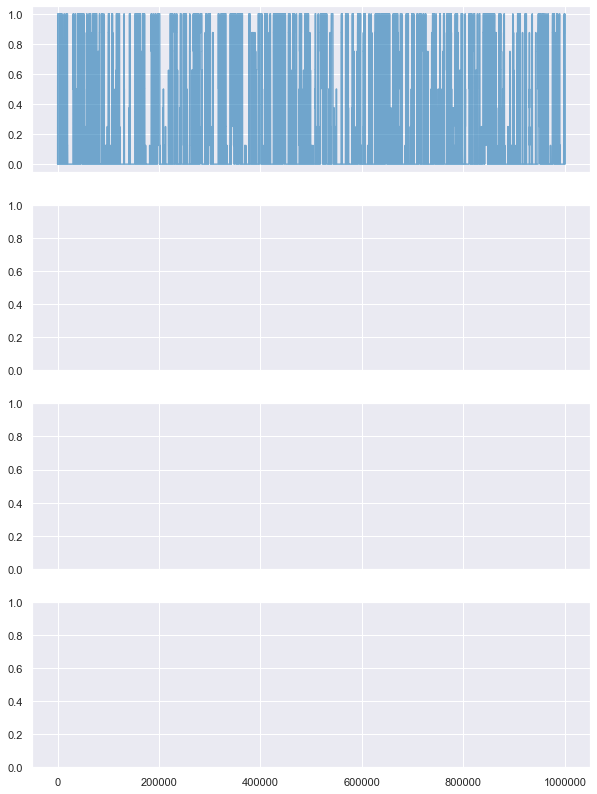

In [12]:
import time

sim = SimulationSymmetricGame(acts, 
                              payouts,
                              max_pos_pressure, 
                              max_neg_pressure,
                              num_players, 
                              num_rounds, 
                              acts_fmt, 
                              coop_act, 
                              defect_act,
                              tolerance,
                              adv_mutation_rate,
                              weight_of_present_for_move,
                              weight_of_present_for_adv,
                              move_increment,
                              move_mutation_rate,
                              adv_conservativity,
                              move_conservativity)

#sim.create_players(init_players_data)


print("Num players: {}".format(sim.num_players))
print("players: {}".format([p.advocate() for p in sim.players]))

time.sleep(2.5)
# run the simulation (uncomment following line)
sim.run()

# display the graph(uncomment following line)
sim.display_round_graph()


creating the graph...

create graph......


Text(0.5, 1.0, ' ')

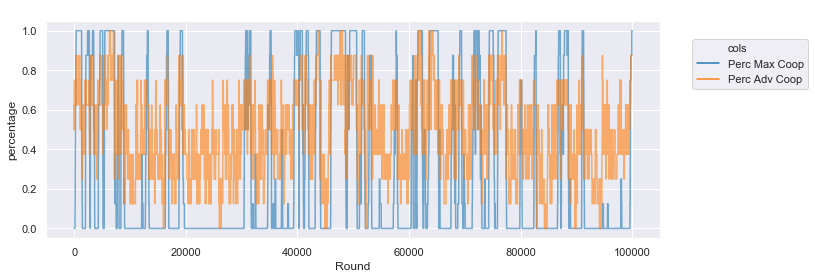

In [18]:
sns.set(rc={'figure.figsize':(11,4)})
print("\ncreating the graph...\n")

fig, axs = plt.subplots(nrows=1)
c = sim.coop
d = sim.defect
            
title_string = " "
round_data = list()
max_C_count = 0
min_C_count = 0
max_adv_C_count = 0
min_adv_C_count = 0
num_adv_c_play_c = 0
num_adv_c_play_d = 0
num_adv_d_play_c = 0
num_adv_d_play_d = 0
num_pds = 0

for rnum,r in enumerate(sim.results[1:100000]):
            
    min_max_c_prob  = 0.9 - 0.8 * sim.move_mutation_rate
    max_min_c_prob  = 0.1 + 0.8 * sim.move_mutation_rate
            
    max_C_count +=  r["avg_prob_coop"] >= min_max_c_prob 
    min_C_count +=  r["avg_prob_coop"] <= max_min_c_prob
            
    max_adv_C_count += (float(r["num_adv_coop"]) / len(r["players"]))  >= (1 - 2 * sim.adv_mutation_rate)
    min_adv_C_count += (float(r["num_adv_coop"]) / len(r["players"]))  <= 2 * sim.adv_mutation_rate

    num_adv_c_play_c += r["p1_move"] == sim.coop and r["p1_adv"] == sim.coop
    num_adv_c_play_c += r["p2_move"] == sim.coop and r["p2_adv"] == sim.coop

    num_adv_c_play_d += r["p1_move"] == sim.coop and r["p1_adv"] == sim.defect
    num_adv_c_play_d += r["p2_move"] == sim.coop and r["p2_adv"] == sim.defect

    num_adv_d_play_c += r["p1_move"] == sim.defect and r["p1_adv"] == sim.coop
    num_adv_d_play_c += r["p2_move"] == sim.defect and r["p2_adv"] == sim.coop

    num_adv_d_play_d += r["p1_move"] == sim.defect and r["p1_adv"] == sim.defect
    num_adv_d_play_d += r["p2_move"] == sim.defect and r["p2_adv"] == sim.defect

    num_pds += r["is_pd"]

    perc_coop = float(sum(p.pr_coop >= min_max_c_prob for p in r["players"])) / len(r["players"])
    perc_defect = float(sum(p.pr_coop <= max_min_c_prob for p in r["players"])) / len(r["players"])
    perc_adv_coop = float(sum(p.advocate() == p.coop for p in r["players"])) / len(r["players"])
    perc_adv_defect = float(sum(p.advocate() == p.defect for p in r["players"])) / len(r["players"])

    cc = sim.payout(c, c)
    cd = sim.payout(c, d)
    dc = sim.payout(d, c)
    dd = sim.payout(d, d)

    round_data.append([rnum,
                               r["avg_prob_coop"],
                               perc_coop,
                               perc_defect,
                               perc_adv_coop,
                               perc_adv_defect,
                               r["avg_coop_increase"],                               
                               r["avg_coop_decrease"],
                               "C" if r["p1_move"] == c else "D",
                               r["p1_payout"],
                               "C" if r["p2_move"] == c else "D",
                               r["p2_payout"],
                               r["updated_game"],
                               r["is_pd"],
                               r["game"].payout_from_tuple(c,c),
                               r["game"].payout_from_tuple(c,d),
                               r["game"].payout_from_tuple(d,c),
                               r["game"].payout_from_tuple(d,d)])


        # Create the pandas DataFrame for round data
            
round_df = pd.DataFrame(round_data,
                                columns = ['Round',
                                           'Avg Pr Coop',
                                           'Perc Max Coop',
                                           'Perc Max Defect',
                                           'Perc Adv Coop',
                                           'Adv Defect',
                                           'Avg Coop Inc',
                                           'Avg Coop Dec',
                                           'P1 Move',
                                           'P1 Payout',
                                           'P2 Move',
                                           'P2 Payout',
                                           'Updated Game',
                                           'PD',
                                           'CC Payout',
                                           'CD Payout',
                                           'DC Payout',
                                           'DD Paytout']) 


print("create graph......")
sim_d = round_df[['Round',"Perc Max Coop", "Perc Adv Coop"]]

sd = sim_d.melt('Round', var_name='cols',  value_name='vals')


theplt1 = sns.lineplot(x="Round", y="vals", hue='cols', 
                                           size='cols', sizes=(1.5,1.5), 
                                           alpha=0.6, palette="tab10",  
                                           data=sd , ax=axs)
axs.set_ylim(-0.05,1.05)
axs.set_ylabel("percentage")
theplt1.legend(loc='center right', bbox_to_anchor=(1.25, 0.8), ncol=1)
theplt1.set_title(title_string)


In [21]:
print([p.avg_payout for p in sim.results[1000]["players"]][0])

4.67037037037
